<a href="https://colab.research.google.com/github/EstevaoMO/machine-learning-aprendizadodemaquina/blob/main/02_dados_e_preprocessamento/colabs/Escalonamento_e_Padroniza%C3%A7%C3%A3o_de_Dados.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Escalonando e Padronizando Dados**

## **1. A Ilusão da Magnitude**

Modelos de aprendizado de máquina são, em sua essência, motores matemáticos cegos. Salvo algumas exceções (como algoritmos baseados em árvores), eles não apresentam bom desempenho quando os atributos numéricos de entrada possuem escalas muito diferentes.

A escala das variáveis importa de forma crítica, pois algoritmos que calculam distâncias geométricas darão um peso artificialmente maior a qualquer variável que possua uma escala maior.

Para explorarmos esse fenômeno, utilizaremos o dataset **Auto MPG**, focando em prever o consumo de combustível (`mpg`) utilizando o peso do veículo (`weight`) e o tempo de aceleração (`acceleration`).

> O peso dos carros varia na casa dos milhares, enquanto a aceleração varia em unidades pequenas. Para um cálculo de distância euclidiana, uma variação de 1.000 libras esmagará completamente o impacto de 5 segundos de aceleração. Como balanceamos isso?

Para testar a resiliência das nossas técnicas, injetaremos um ruído comum da indústria; simularemos um erro humano, adicionando um zero a mais no peso de um carro qualquer. Esse valor servirá como um outlier na nossa base.

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = sns.load_dataset('mpg').dropna()
X = df[['weight', 'acceleration']] # Features
y = df['mpg'] # Rótulo

indice_erro = df.index[-1]
df.loc[indice_erro, 'weight'] = df.loc[indice_erro, 'weight'] * 10
X = df[['weight', 'acceleration']]

print("Amostra dos dados (Observe a discrepância de escalas e o erro na última linha):")
display(X.tail(3))

Amostra dos dados (Observe a discrepância de escalas e o erro na última linha):


,weight,acceleration
395,2295,11.6
396,2625,18.6
397,27200,19.4


## **2. Escalonamento Min-Max (Normalization)**

O `MinMaxScaler` não se preocupa com medidas de tendência central, como a média ou o desvio padrão. O seu objetivo é espremer todos os dados para que caibam dentro de um intervalo fixo, que por padrão é entre $0$ e $1$. O menor valor da base assume $0$ e o maior assume $1$.

$$x_{scaled} = \frac{x - x_{min}}{x_{max} - x_{min}}$$

*   **Vantagem:** Preserva rigorosamente o limite do espaço (tudo estará entre 0 e 1), útil para algoritmos que exigem limites estritos (como Redes Neurais clássicas).
*   **Desvantagem:** É altamente sensível a outliers. No nosso cenário, o valor máximo ($x_{max}$) do peso não é o carro mais pesado real, mas sim o nosso erro de digitação absurdo. Isso forçará todos os dados normais para o fundo da escala, próximos ao $0$.

In [ ]:
from sklearn.preprocessing import MinMaxScaler

scaler_minmax = MinMaxScaler()
X_minmax = pd.DataFrame(scaler_minmax.fit_transform(X), columns=['weight_MinMax', 'accel_MinMax'])

print("Estatísticas após Min-Max:")
display(X_minmax.describe().round(3).loc[['min', 'mean', 'max']])

Estatísticas após Min-Max:


,weight_MinMax,accel_MinMax
min,0.000,0.000
mean,0.056,0.449
max,1.000,1.000


## **3. Padronização Z-score (Standardization)**

O `StandardScaler` é a técnica cujo objetivo é centralizar os dados, forçando-os a ter uma média aritmética igual a zero ($\mu = 0$) e um desvio padrão igual a um ($\sigma = 1$).

$$x_{scaled} = \frac{x - \mu}{\sigma}$$

*   **Vantagem:** Geometricamente, essa transformação desloca a distribuição para o centro do eixo coordenado, mas preserva a forma original da curva. É excelente para convergência de gradientes.
*   **Desvantagem:** A padronização não impõe limite rígido, permitindo que extremos continuem distantes como desvios padrão. Além disso, como a média ($\mu$) é sensível a outliers, o nosso erro de digitação vai "puxar" a média da base, descentralizando levemente os dados normais.

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler_std = StandardScaler()
X_std = pd.DataFrame(scaler_std.fit_transform(X), columns=['weight_Std', 'accel_Std'])

print("Estatísticas após Z-Score (Observe a média tendendo a 0 e o desvio a 1):")
display(X_std.describe().round(3).loc[['min', 'max', 'mean', 'std']])

Estatísticas após Z-Score (Observe a média tendendo a 0 e o desvio a 1):


,weight_Std,accel_Std
min,-0.959,-2.737
max,16.243,3.360
mean,0.000,0.000
std,1.001,1.001


## **4. Escalonamento Robusto (RobustScaler)**

Técnicas que dependem da média ou do valor máximo falham quando a base possui valores extremos. O `RobustScaler` resolve isso utilizando estatística de ordem;ele subtrai a mediana ($Q_2$) e divide pelo intervalo interquartil (IQR).

$$x_{scaled} = \frac{x - Q_2}{Q_3 - Q_1}$$

*   **Vantagem:** A massa principal dos dados é escalonada corretamente e os outliers são isolados, pois o método ignora completamente os valores extremos para calcular seus parâmetros.
*   **Desvantagem:** Não confina os dados em um limite de escala fixo e a variância final não será estritamente unitária, o que pode desagradar alguns algoritmos matemáticos.

In [ ]:
from sklearn.preprocessing import RobustScaler

scaler_robust = RobustScaler()
X_robust = pd.DataFrame(scaler_robust.fit_transform(X), columns=['weight_Robust', 'accel_Robust'])

print("Estatísticas após RobustScaler:")
display(X_robust.describe().round(3).loc[['min', 'max', 'mean', 'std']])

Estatísticas após RobustScaler:


,weight_Robust,accel_Robust
min,-0.857,-2.308
max,17.455,2.862
mean,0.164,0.013
std,1.066,0.849


## **5. Comparativo Visual das Dispersões**

Vamos imprimir os quatro cenários lado a lado. Note atentamente a posição do nosso erro de digitação (o ponto isolado) e o impacto que ele causa no aglomerado de dados válidos.

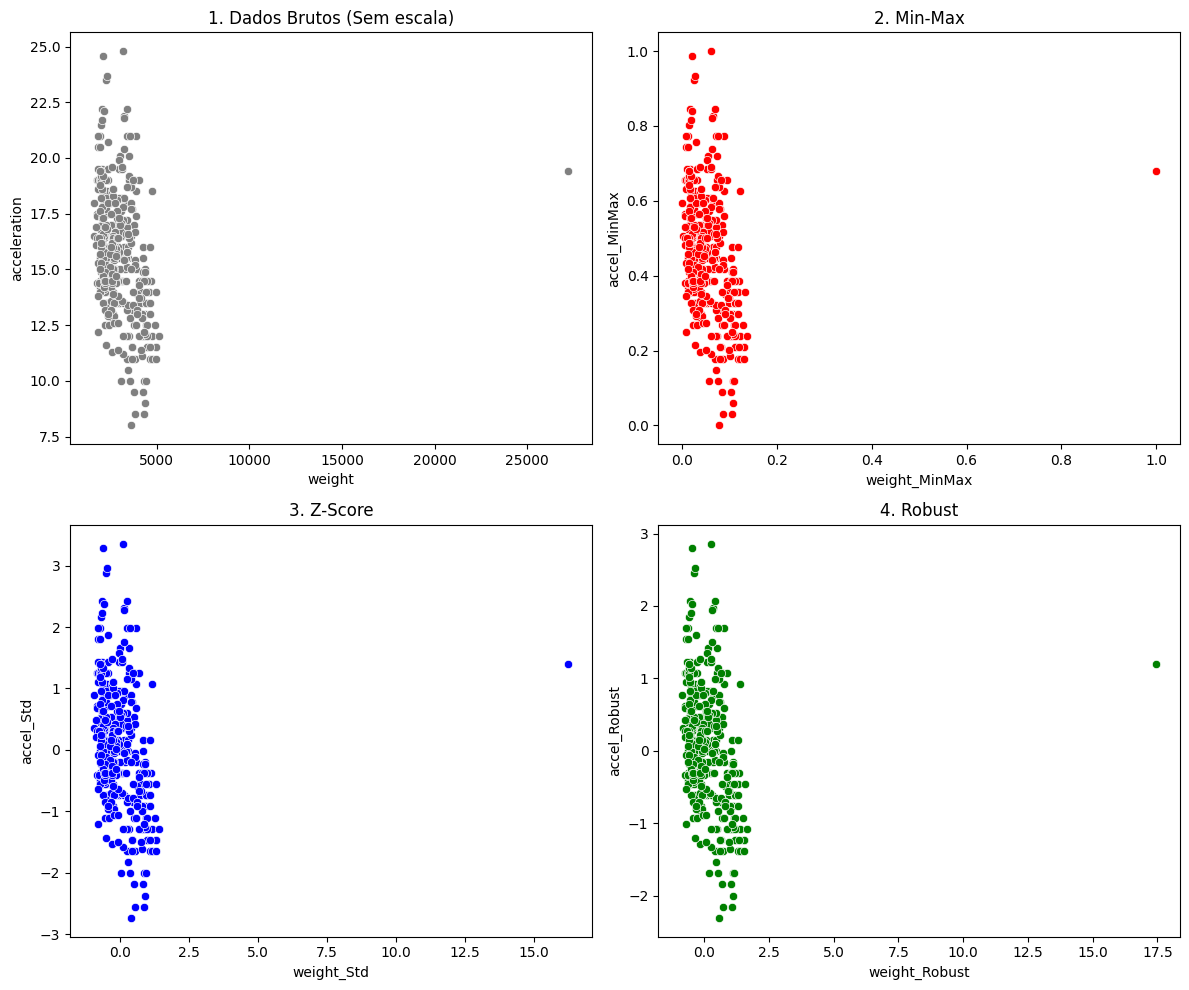

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

sns.scatterplot(x=X['weight'], y=X['acceleration'], ax=axes[0], color='gray')
axes[0].set_title("1. Dados Brutos (Sem escala)")

sns.scatterplot(x=X_minmax['weight_MinMax'], y=X_minmax['accel_MinMax'], ax=axes[1], color='red')
axes[1].set_title("2. Min-Max")

sns.scatterplot(x=X_std['weight_Std'], y=X_std['accel_Std'], ax=axes[2], color='blue')
axes[2].set_title("3. Z-Score")

sns.scatterplot(x=X_robust['weight_Robust'], y=X_robust['accel_Robust'], ax=axes[3], color='green')
axes[3].set_title("4. Robust")

plt.tight_layout()
plt.show()

## **6. Desempenho no Modelo**

Visualizar a dispersão é excelente para a intuição, mas como isso afeta as métricas do negócio?

Para demonstrar o impacto prático, treinaremos um modelo de Regressão Linear baseado em otimização iterativa (`SGDRegressor`). Modelos que buscam o mínimo da função de custo via gradiente descendente colapsam se as variáveis não estiverem na mesma escala, pois as variáveis grandes farão o peso explodir a cada iteração.

**Regra de Ouro:** Para garantir uma estimativa de erro estatisticamente válida, precisamos separar o conjunto de teste imediatamente, antes de aplicar o escalonamento. A função `fit` deve extrair seus parâmetros matemáticos exclusivamente dos dados de treino.

In [ ]:
from sklearn.linear_model import SGDRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
import warnings
warnings.filterwarnings('ignore')

# treino e teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# treinando modelo com standardization
X_train_std = scaler_std.fit_transform(X_train)
X_test_std = scaler_std.transform(X_test)

# treinando modelo com robust scaling
X_train_robust = scaler_robust.fit_transform(X_train)
X_test_robust = scaler_robust.transform(X_test)

# instanciando modelo de regressão (versão não escalonada)
modelo_bruto = SGDRegressor(random_state=42, max_iter=1000)
modelo_bruto.fit(X_train, y_train)

# instanciando modelo da versão StandardScaler
modelo_std = SGDRegressor(random_state=42, max_iter=1000)
modelo_std.fit(X_train_std, y_train)

# instanciando modelo da versão RobustScaler
modelo_robust = SGDRegressor(random_state=42, max_iter=1000)
modelo_robust.fit(X_train_robust, y_train)


erro_bruto = mean_squared_error(y_test, modelo_bruto.predict(X_test))
erro_std = mean_squared_error(y_test, modelo_std.predict(X_test_std))
erro_robust = mean_squared_error(y_test, modelo_robust.predict(X_test_robust))

print("--- DESEMPENHO PREDITIVO (ERRO QUADRÁTICO MÉDIO) ---")
print(f"Dados Brutos (gradiente colapsou): {erro_bruto:,.0f} (milhas/galão)² de erro")
print(f"Dados Padronizados (Std):  {erro_std:,.2f} (milhas/galão)² de erro")
print(f"Dados Robustos (Robust):   {erro_robust:,.2f} (milhas/galão)² de erro")

--- DESEMPENHO PREDITIVO (ERRO QUADRÁTICO MÉDIO) ---
Dados Brutos (gradiente colapsou): 72,017,481,267,977,532,557,897,544,761,344 (milhas/galão)² de erro
Dados Padronizados (Std):  30.37 (milhas/galão)² de erro
Dados Robustos (Robust):   29.79 (milhas/galão)² de erro


**Conclusão:**

Observe o absurdo preditivo gerado pelos dados brutos. Como a coluna do peso oscilava na casa dos milhares e possuía um *outlier* grave, a matemática do algoritmo se perdeu, gerando um erro irreal.

Ao padronizarmos a escala, reduzimos a taxa de erro para casas decimais controladas. Note, inclusive, como o `RobustScaler` apresenta uma leve margem de vitória sobre o `StandardScaler` neste cenário, justamente por não ter permitido que o erro de digitação alterasse o centro de massa do aprendizado.